# Atölye — Nesne Tespiti, Takip ve Sayma

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gorkenvm/Presentations/blob/main/cnn2/atolye_yolo.ipynb)

Dün **sınıflandırma** yaptık: bir fotoğrafa bakıp "bu ne?" diye sorduk.
Bugün soruyu değiştiriyoruz: **"ne var, nerede, kaç tane?"**

Akış tek bir mantıkla ilerliyor — her adım bir öncekinin cevaplayamadığı soruyu çözüyor:

| Adım | Cevapladığı soru |
|---|---|
| **Tespit** | Bu karede ne var ve nerede? |
| **Takip** | Bu, az önceki nesnenin aynısı mı? |
| **Sayma** | Şu çizgiden kaç tane geçti? |

> **Başlamadan:** Menüden **Çalışma zamanı → Çalışma zamanı türünü değiştir → T4 GPU**.
> GPU olmadan fotoğraflar çalışır ama videolar çok yavaşlar.

---
## 0. Kurulum ve veri

In [ ]:
!pip install -q ultralytics

import os, zipfile, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from ultralytics import YOLO

print("Torch:", torch.__version__, "| GPU:", torch.cuda.is_available())
if not torch.cuda.is_available():
    print("  → GPU yok. Fotoğraflar çalışır, videolar yavaş olur.")

In [ ]:
# Atölye görselleri ve videoları — GitHub'dan
URL = ("https://raw.githubusercontent.com/gorkenvm/Presentations/main/"
       "cnn2/veri/atolye_gorseller.zip")

zip_yolu = "/content/atolye_gorseller.zip"
if not os.path.exists(zip_yolu):
    urllib.request.urlretrieve(URL, zip_yolu)
with zipfile.ZipFile(zip_yolu) as z:
    z.extractall("/content")

GORUNTU_DIZIN = "/content/atolye/goruntuler"
VIDEO_DIZIN   = "/content/atolye/video"

print("Görüntüler:", sorted(os.listdir(GORUNTU_DIZIN)))
print("Videolar  :", sorted(os.listdir(VIDEO_DIZIN)))

In [ ]:
# --- yardımcılar ---

def goster(gorsel_bgr, baslik="", genislik=11):
    # OpenCV BGR görüntüsünü notebook'ta gösterir
    rgb = cv2.cvtColor(gorsel_bgr, cv2.COLOR_BGR2RGB)
    oran = rgb.shape[0] / rgb.shape[1]
    plt.figure(figsize=(genislik, genislik * oran))
    plt.imshow(rgb)
    plt.title(baslik, fontsize=12)
    plt.axis("off")
    plt.show()


def model_yukle(tercihler=("yolo26n.pt", "yolo11n.pt", "yolov8n.pt")):
    # Sürüm farklarına karşı: ilk indirilebileni kullan
    for ad in tercihler:
        try:
            m = YOLO(ad)
            print("Model:", ad)
            return m
        except Exception as e:
            print(f"  {ad} yüklenemedi ({type(e).__name__}), sıradakine geçiliyor")
    raise RuntimeError("Hiçbir model yüklenemedi")


model = model_yukle()
print("Tanıdığı sınıf sayısı:", len(model.names))

---
# 1. Dünkü model neden yetmiyor?

Dün eğittiğimiz gibi bir sınıflandırıcı alalım ve içinde **birden çok nesne olan**
bir fotoğrafı verelim.

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import (
    MobileNetV2, preprocess_input, decode_predictions)
from tensorflow.keras.utils import load_img, img_to_array

siniflandirici = MobileNetV2(weights="imagenet")     # dünkü gövdenin tam hali

FOTO = os.path.join(GORUNTU_DIZIN, "traffic.jpg")

img = load_img(FOTO, target_size=(224, 224))
x = preprocess_input(np.expand_dims(img_to_array(img), 0))
tahmin = decode_predictions(siniflandirici.predict(x, verbose=0), top=3)[0]

goster(cv2.imread(FOTO), "Sınıflandırıcıya verdiğimiz fotoğraf")

print("Sınıflandırıcının cevabı:")
for _, ad, olasilik in tahmin:
    print(f"  {ad:22s} {olasilik:.3f}")

Model **tek bir cevap** verdi. Oysa fotoğrafta onlarca araç, yaya ve trafik ışığı var.

**Model yanlış mı söyledi?** Hayır. Sorduğumuz soru yanlıştı.

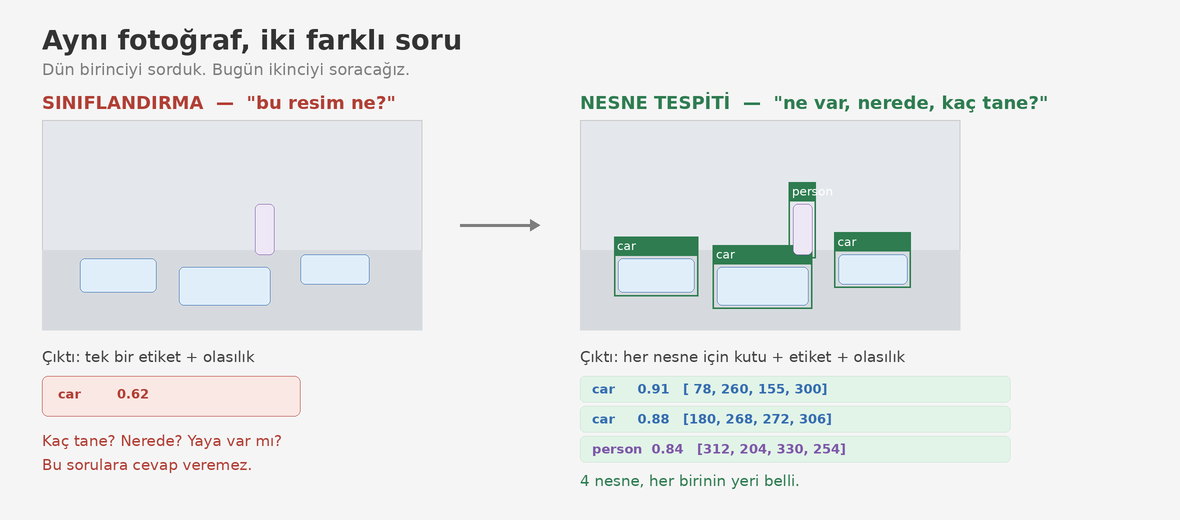

---
# 2. Aynı fotoğraf, bu kez tespit

Üç satır. Aynı fotoğraf.

In [ ]:
sonuclar = model(FOTO, verbose=False)
goster(sonuclar[0].plot(), "YOLO ile nesne tespiti")

print(f"Bulunan nesne sayısı: {len(sonuclar[0].boxes)}")

In [ ]:
# Ne bulduğuna sınıf sınıf bakalım
from collections import Counter

sinif_idler = sonuclar[0].boxes.cls.int().tolist()
sayim = Counter(model.names[i] for i in sinif_idler)

for ad, adet in sayim.most_common():
    print(f"  {ad:16s} {adet}")

Az önce tek cevap veren fotoğraf, şimdi her nesneyi ayrı ayrı veriyor — **üstelik yeriyle**.

Diğer fotoğraflara da bakalım.

In [ ]:
from glob import glob

yollar = sorted(glob(os.path.join(GORUNTU_DIZIN, "*.jpg")))[:6]
toplu = model(yollar, verbose=False)

plt.figure(figsize=(16, 9))
for i, (yol, sonuc) in enumerate(zip(yollar, toplu)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(cv2.cvtColor(sonuc.plot(), cv2.COLOR_BGR2RGB))
    plt.title(f"{os.path.basename(yol)} — {len(sonuc.boxes)} nesne", fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.show()

---
# 3. Çıktının anatomisi

Ekranda gördüğümüz renkli kutuların altında ne var?

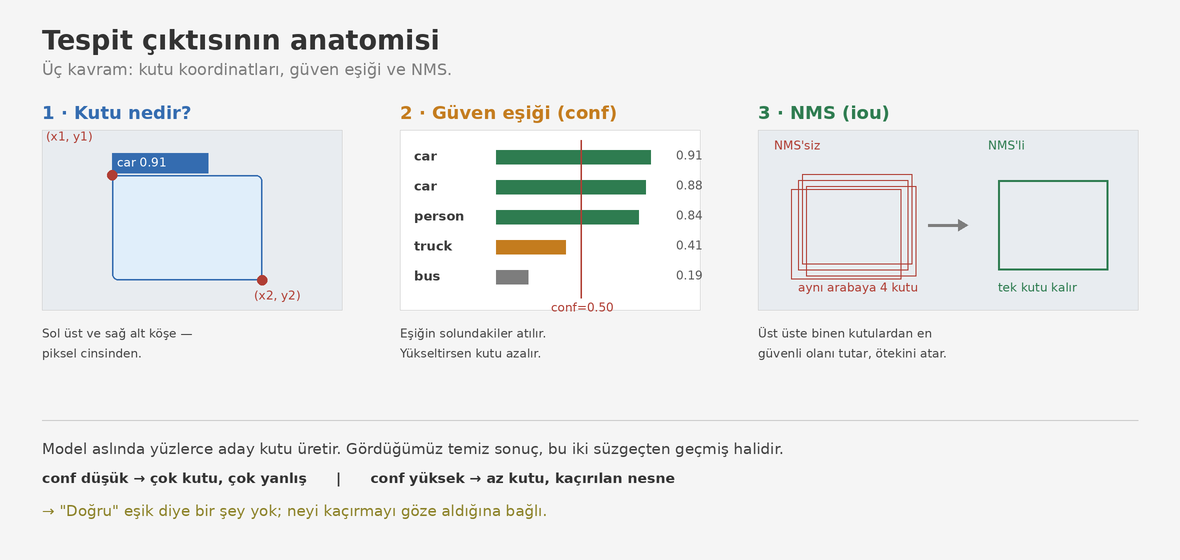

In [ ]:
kutular = sonuclar[0].boxes

print(f"{'sınıf':14s} {'güven':>7s}   kutu (x1, y1, x2, y2)")
print("-" * 58)
for kutu in kutular[:8]:
    ad  = model.names[int(kutu.cls)]
    gvn = float(kutu.conf)
    x1, y1, x2, y2 = [int(v) for v in kutu.xyxy[0]]
    print(f"{ad:14s} {gvn:7.3f}   ({x1:4d}, {y1:4d}, {x2:4d}, {y2:4d})")

print(f"\nToplam {len(kutular)} kutu.")

## 3.1 Güven eşiği ile oynayalım

`conf` parametresi, "şu olasılığın altındakileri bana gösterme" demek.
Aynı fotoğrafı üç farklı eşikle çalıştıralım.

In [ ]:
esikler = [0.10, 0.25, 0.60]

plt.figure(figsize=(17, 6))
for i, esik in enumerate(esikler):
    s = model(FOTO, conf=esik, verbose=False)[0]
    plt.subplot(1, 3, i + 1)
    plt.imshow(cv2.cvtColor(s.plot(), cv2.COLOR_BGR2RGB))
    plt.title(f"conf = {esik}  →  {len(s.boxes)} nesne", fontsize=12)
    plt.axis("off")
plt.tight_layout()
plt.show()

Eşik düştükçe kutu sayısı artıyor — ama artan kutuların bir kısmı **yanlış**.
Eşik yükseldikçe sonuç temizleniyor — ama bu sefer gerçek nesneleri **kaçırıyoruz**.

> "Doğru" eşik diye bir şey yok. Güvenlik kamerasında hiçbir şeyi kaçırmak istemezsin,
> eşiği düşürürsün. Otomatik bir sayım sisteminde yanlış saymak istemezsin, yükseltirsin.

## 3.2 NMS: aynı nesneye kaç kutu?

Model aslında **yüzlerce** aday kutu üretir; aynı arabanın üstüne onlarca kutu düşer.
NMS (Non-Maximum Suppression) üst üste binenleri temizler.

`iou` parametresi "ne kadar üst üste binerlerse aynı sayılsın" eşiğidir.
Yükseltirsek NMS gevşer ve kopyalar kalmaya başlar.

In [ ]:
iou_degerleri = [0.30, 0.70, 0.95]

plt.figure(figsize=(17, 6))
for i, iou in enumerate(iou_degerleri):
    s = model(FOTO, iou=iou, conf=0.25, verbose=False)[0]
    plt.subplot(1, 3, i + 1)
    plt.imshow(cv2.cvtColor(s.plot(), cv2.COLOR_BGR2RGB))
    plt.title(f"iou = {iou}  →  {len(s.boxes)} kutu", fontsize=12)
    plt.axis("off")
plt.tight_layout()
plt.show()

`iou = 0.95`'te aynı nesnenin üstünde birden fazla kutu görünmeye başlıyor —
NMS'in ne işe yaradığı en iyi böyle anlaşılıyor.

---
# 4. Videoya geçelim

Video, arka arkaya dizilmiş fotoğraflardan başka bir şey değil. Modele **her kareyi
ayrı ayrı** vereceğiz.

In [ ]:
from IPython.display import HTML
from base64 import b64encode

VIDEO = os.path.join(VIDEO_DIZIN, "car_flow.mp4")


def video_goster(yol, genislik=720):
    # Tarayıcıda oynatilabilmesi icin H.264'e cevirip gomer
    duzeltilmis = yol.replace(".mp4", "_h264.mp4")
    os.system(f'ffmpeg -y -loglevel error -i "{yol}" -vcodec libx264 '
              f'-pix_fmt yuv420p "{duzeltilmis}"')
    veri = open(duzeltilmis, "rb").read()
    src = "data:video/mp4;base64," + b64encode(veri).decode()
    return HTML(f'<video width={genislik} controls loop>'
                f'<source src="{src}" type="video/mp4"></video>')


video_goster(VIDEO)

In [ ]:
def videoyu_isle(giris, cikis, islem, max_kare=None):
    # Videoyu kare kare isler. islem(kare, i) -> cizilmis kare
    cap = cv2.VideoCapture(giris)
    assert cap.isOpened(), f"Video açılamadı: {giris}"

    en  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    boy = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25

    yazici = cv2.VideoWriter(cikis, cv2.VideoWriter_fourcc(*"mp4v"), fps, (en, boy))

    i = 0
    while True:
        ok, kare = cap.read()
        if not ok or (max_kare and i >= max_kare):
            break
        yazici.write(islem(kare, i))
        i += 1

    cap.release()
    yazici.release()
    print(f"{i} kare işlendi → {cikis}")
    return cikis


# Her kareyi ayrı ayrı tespit et
model_tespit = model_yukle()

def sadece_tespit(kare, i):
    return model_tespit(kare, verbose=False)[0].plot()

videoyu_isle(VIDEO, "/content/01_tespit.mp4", sadece_tespit)
video_goster("/content/01_tespit.mp4")

İşe yarıyor. Ama bir sorun var.

> **Sorun:** Model her kareye **sıfırdan** bakıyor. 5. karedeki kırmızı arabanın,
> 4. karedeki kırmızı arabayla aynı araba olduğunu bilmiyor. Onun için her kare
> yepyeni bir dünya.

Bu yüzden "kaç araba geçti?" sorusunu **tespit tek başına cevaplayamaz.**

---
# 5. Takip — nesnelere kimlik vermek

`track()`, tespitin üstüne bir katman ekler: her nesneye bir **ID** atar ve
kareler arasında onu izler.

In [ ]:
model_takip = model_yukle()

def takip_et(kare, i):
    return model_takip.track(kare, persist=True, verbose=False)[0].plot()

videoyu_isle(VIDEO, "/content/02_takip.mp4", takip_et)
video_goster("/content/02_takip.mp4")

Kutuların üstünde artık `id:3`, `id:7` gibi numaralar var. Aynı araba boyunca
**aynı numara** kalıyor.

Şimdi izlerini de çizelim — her nesnenin nereden gelip nereye gittiği görünsün.

In [ ]:
from collections import defaultdict

model_iz = model_yukle()
izler = defaultdict(list)

def iz_ciz(kare, i):
    sonuc = model_iz.track(kare, persist=True, verbose=False)[0]
    cizim = sonuc.plot()

    if sonuc.boxes.id is not None:
        merkezler = sonuc.boxes.xywh.cpu()
        idler = sonuc.boxes.id.int().cpu().tolist()

        for (x, y, w, h), nesne_id in zip(merkezler, idler):
            iz = izler[nesne_id]
            iz.append((float(x), float(y)))
            if len(iz) > 40:                       # son 40 kare yeter
                iz.pop(0)
            if len(iz) > 1:
                nokta = np.array(iz, np.int32).reshape((-1, 1, 2))
                cv2.polylines(cizim, [nokta], False, (60, 200, 90), 3)
    return cizim

videoyu_isle(VIDEO, "/content/03_iz.mp4", iz_ciz)
video_goster("/content/03_iz.mp4")

> **Neden ayrı bir problem?** Tespit "şu anda ne var" sorusunu cevaplar.
> Takip "bu, az önceki miydi" sorusunu cevaplar. İkincisi için modelin
> **hafızaya** ihtiyacı var — `persist=True` tam da bunu sağlıyor.

---
# 6. Sayma — çizgiden kaç tane geçti?

Artık her nesnenin kimliği olduğuna göre sayabiliriz: bir **bölge** çizip
oradan geçen ID'leri sayacağız.

In [ ]:
from ultralytics import solutions

VIDEO2 = os.path.join(VIDEO_DIZIN, "people.m4v")

# Videonun ilk karesine bakıp bölgeyi nereye koyacağımıza karar verelim
cap = cv2.VideoCapture(VIDEO2)
ok, ilk_kare = cap.read()
cap.release()
print("Video boyutu:", ilk_kare.shape[1], "x", ilk_kare.shape[0])
goster(ilk_kare, "people.m4v — ilk kare", genislik=8)

In [ ]:
# Sayım bölgesi: dikey bir kapı. Koordinatlar yukarıdaki kareye göre.
bolge = [(360, 140), (360, 390), (410, 390), (410, 140)]

onizleme = ilk_kare.copy()
cv2.polylines(onizleme, [np.array(bolge, np.int32)], True, (0, 0, 255), 3)
goster(onizleme, "Sayım bölgesi", genislik=8)

In [ ]:
sayaci = solutions.ObjectCounter(
    region=bolge,
    model="yolo11n.pt",     # yolo26n.pt de kullanılabilir
    classes=[0],            # 0 = person, sadece insan sayalım
    show=False,
    verbose=False,
)

son_sonuc = {}

def say(kare, i):
    r = sayaci(kare)
    son_sonuc["r"] = r          # toplamları sonra yazdırmak için sakla
    return r.plot_im

videoyu_isle(VIDEO2, "/content/04_sayim.mp4", say, max_kare=400)

r = son_sonuc["r"]
print(f"Bölgeye giren : {r.in_count}")
print(f"Bölgeden çıkan: {r.out_count}")
print(f"Sınıf bazında : {r.classwise_count}")

video_goster("/content/04_sayim.mp4")

Sol üstteki sayaç, bölgeden **giren** ve **çıkan** kişileri ayrı ayrı tutuyor.

Bu, mağaza girişinde müşteri sayan, kavşakta araç sayan, fabrikada ürün sayan
sistemlerin tam olarak yaptığı iş.

---
# 7. Kendi görüntünüzle deneyin

Üç yol var. Hangisi kolayınıza gelirse.

**a) İnternetten bir görsel adresi**

In [ ]:
GORSEL_URL = "https://ultralytics.com/images/bus.jpg"   # kendi linkinizi yazın

s = model(GORSEL_URL, verbose=False)[0]
goster(s.plot(), f"{len(s.boxes)} nesne bulundu")

**b) Bilgisayardan / telefondan dosya yükleme**

In [ ]:
from google.colab import files

yuklenen = files.upload()          # dosya seçme penceresi açılır

for ad in yuklenen:
    s = model(ad, verbose=False)[0]
    goster(s.plot(), f"{ad} — {len(s.boxes)} nesne")

**c) Webcam ile anlık fotoğraf**

(Tarayıcı kamera izni ister. Çalışmazsa yukarıdaki iki yöntem var.)

In [ ]:
from IPython.display import Javascript, display
from google.colab.output import eval_js

def webcam_foto(dosya="/content/webcam.jpg", kalite=0.9):
    display(Javascript('''
        async function cek(kalite) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Fotoğraf çek';
            div.appendChild(capture);
            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();
            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
            await new Promise((resolve) => capture.onclick = resolve);
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', kalite);
        }
    '''))
    veri = eval_js(f"cek({kalite})")
    from base64 import b64decode
    with open(dosya, "wb") as f:
        f.write(b64decode(veri.split(",")[1]))
    return dosya


yol = webcam_foto()
s = model(yol, verbose=False)[0]
goster(s.plot(), f"{len(s.boxes)} nesne bulundu")

---
# 8. Model neyi bulamaz?

YOLO'nun tanıdığı sınıflar **COCO** veri setinden geliyor. Bakalım neler varmış.

In [ ]:
isimler = list(model.names.values())
print(f"Toplam {len(isimler)} sınıf:\n")
for i in range(0, len(isimler), 8):
    print("  " + "  ".join(f"{a:14s}" for a in isimler[i:i+8]))

In [ ]:
# Dün sınıflandırdığımız çöp türleri bu listede var mı?
dunku_siniflar = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

print("Dünkü sınıflar COCO'da var mı?\n")
for s in dunku_siniflar:
    durum = "VAR" if s in isimler else "YOK"
    print(f"  {s:12s} {durum}")

Hiçbiri yok.

> **Demek ki:** Hazır bir tespit modeli sadece **kendisine öğretilmiş** nesneleri bulur.
> Sizin probleminizdeki nesneleri bulmasını istiyorsanız iki yolunuz var:
>
> 1. Birinin o nesneleri etiketleyip eğittiği bir modeli kullanmak
> 2. Kendi verinizi etiketleyip kendiniz eğitmek

Aşağıda birinci yolu göreceğiz.

---
# 9. Dünkü 6 sınıf, bu kez kutu ile

Roboflow Universe, insanların etiketleyip paylaştığı veri setlerinin ve eğitilmiş
modellerin bulunduğu bir depo. Orada **dünkü dersimizin tam olarak aynı sınıflarını**
içeren, tespit için etiketlenmiş bir veri seti var:

**`trash-classification-fg7fz`** — 5742 görüntü
`cardboard, glass, metal, paper, plastic, trash, vinyl`

Bu modeli **eğitmeden**, tek bir API çağrısıyla çalıştırabiliriz.

> Ücretsiz bir Roboflow hesabı ve API anahtarı gerekiyor:
> [app.roboflow.com](https://app.roboflow.com) → Settings → API Keys

In [ ]:
!pip install -q inference-sdk

from inference_sdk import InferenceHTTPClient

ROBOFLOW_API_KEY = ""          # ← kendi anahtarınızı buraya

istemci = InferenceHTTPClient(api_url="https://detect.roboflow.com",
                              api_key=ROBOFLOW_API_KEY)

TEST_GORSEL = os.path.join(GORUNTU_DIZIN, "kitchen.jpg")   # ya da kendi çöp fotoğrafınız

cevap = istemci.infer(TEST_GORSEL, model_id="trash-classification-fg7fz/2")

print(f"{len(cevap['predictions'])} nesne bulundu:\n")
for p in cevap["predictions"]:
    print(f"  {p['class']:12s} {p['confidence']:.3f}   "
          f"merkez=({int(p['x'])}, {int(p['y'])})  "
          f"boyut={int(p['width'])}x{int(p['height'])}")

In [ ]:
# Kutuları kendimiz çizelim — Roboflow merkez + genişlik/yükseklik veriyor
gorsel = cv2.imread(TEST_GORSEL)

for p in cevap["predictions"]:
    x1 = int(p["x"] - p["width"] / 2)
    y1 = int(p["y"] - p["height"] / 2)
    x2 = int(p["x"] + p["width"] / 2)
    y2 = int(p["y"] + p["height"] / 2)

    cv2.rectangle(gorsel, (x1, y1), (x2, y2), (60, 200, 90), 3)
    etiket = f"{p['class']} {p['confidence']:.2f}"
    cv2.rectangle(gorsel, (x1, y1 - 26), (x1 + 11 * len(etiket), y1), (60, 200, 90), -1)
    cv2.putText(gorsel, etiket, (x1 + 4, y1 - 7),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

goster(gorsel, "Roboflow — çöp tespiti (dünkü sınıflar)")

Dikkat edin: **hiçbir eğitim yapmadık.** Birisi 5742 görüntüyü etiketlemiş, eğitmiş
ve paylaşmış. Biz sadece kullandık.

Kendi nesneniz için hazır bir model yoksa yol şu:

1. **Topla** — 200-500 fotoğraf genelde başlangıç için yeter
2. **Etiketle** — her nesnenin etrafına kutu çiz (Roboflow'un etiketleme aracı bunun için)
3. **Eğit** — dünkü transfer learning mantığının aynısı, sadece tespit için
4. **Dene ve düzelt** — modelin kaçırdığı örnekleri veri setine ekle

> Etiketleme, işin en sıkıcı ama en belirleyici kısmıdır. Model kalitesi neredeyse
> tamamen etiket kalitesine bağlıdır.

---
# 10. Toparlayalım

| | Ne yapar | Ne yapamaz |
|---|---|---|
| **Sınıflandırma** | Resmin tamamına tek etiket | Kaç tane, nerede |
| **Tespit** | Her nesneye kutu + etiket | Bu, az önceki mi |
| **Takip** | Nesnelere kimlik verir | Kendi başına saymaz |
| **Sayma** | Bölgeden geçenleri sayar | Öğretilmemiş nesneyi bulamaz |

**Aklınızda kalsın:**

- `conf` ve `iou` sonucu doğrudan değiştirir — "doğru" değer probleme göre değişir.
- Hazır model sadece öğretildiği sınıfları bulur. COCO'da 80 sınıf var, sizinki
  muhtemelen yok.
- Kendi nesnenizi bulmak istiyorsanız iş etiketlemeden geçiyor.

**Bundan sonra deneyebilecekleriniz:**

- `yolo26n.pt` yerine `yolo26s.pt` veya `yolo26m.pt` — daha yavaş, daha doğru
- `model.track(..., tracker="botsort.yaml")` — farklı takip algoritması
- Segmentasyon modeli (`-seg` ekli) — kutu yerine piksel maskesi
- Poz tahmini (`-pose` ekli) — insan iskeleti
- Kendi veri setinizi etiketleyip eğitmek